# Eye Disease Classification (Week 1)

CNN from scratch + DenseNet121 + EfficientNetB0 fine-tuned on the 8-class fundus dataset, ending with an ensemble of the two pretrained models.

## 1. Get the dataset from Drive

In [1]:
!pip install -q gdown

In [2]:
import gdown

FILE_ID = '1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS'
gdown.download(id=FILE_ID, output='/kaggle/working/EyeDiseaseDataset.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS
From (redirected): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS&confirm=t&uuid=fb321262-0a70-45de-b899-6b7421934d58
To: /kaggle/working/EyeDiseaseDataset.zip
100%|██████████| 4.08G/4.08G [00:46<00:00, 87.1MB/s]


'/kaggle/working/EyeDiseaseDataset.zip'

In [3]:
!unzip -q /kaggle/working/EyeDiseaseDataset.zip -d /kaggle/working/data

## 2. Imports

In [4]:
import glob, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models , op
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3. Explore the dataset files

In [5]:
root = os.path.dirname(glob.glob('/kaggle/working/data/**/metadata.csv', recursive=True)[0])
print(root)
print(os.listdir(root))

/kaggle/working/data
['catalog', 'splits', 'metadata.csv', 'Tasks_and_Classes.md', 'images']


In [6]:
with open(os.path.join(root, 'Tasks_and_Classes.md')) as f:
    print(f.read())

# Eye Disease Dataset: Available Tasks & Class Descriptions

This document outlines the computer vision and machine learning tasks that can be accomplished using the unified Eye Disease Dataset, along with a detailed medical description of the 8 disease classes present in the corpus.

---

## Part 1: Available Machine Learning Tasks

Given the scale (11,839 images), diversity (4 distinct data sources), and distribution of this dataset, you can perform several advanced machine learning tasks:

### 1. Multi-class Image Classification
The most direct application is training Convolutional Neural Networks (CNNs) like ResNet or DenseNet, or Vision Transformers (ViTs), to categorize a fundus image into one of the 8 discrete classes. This acts as a comprehensive diagnostic assistant.

### 2. Binary Screening (Disease vs. Normal)
You can subset the dataset to build highly specialized, high-accuracy binary classifiers. Examples include:
- **General Screening:** Normal vs. Abnormal (All other cla

In [7]:
meta = pd.read_csv(os.path.join(root, 'metadata.csv'))
val_csv = pd.read_csv(os.path.join(root, 'splits', 'val.csv'))
print(meta.shape, val_csv.shape)
meta.head()

(11839, 4) (1197, 4)


,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal


In [8]:
# columns confirmed from metadata.csv, matching images by file name in case they are in subfolders
FILE_COL = 'filename'
LABEL_COL = 'unified_label'

images_dir = os.path.join(root, 'images')
file_map = {f: os.path.join(d, f) for d, _, fs in os.walk(images_dir) for f in fs}

meta['name'] = meta[FILE_COL].astype(str).apply(os.path.basename)
meta['path'] = meta['name'].map(file_map)
print('missing image files:', meta['path'].isna().sum())
meta = meta.dropna(subset=['path']).reset_index(drop=True)

classes = sorted(meta[LABEL_COL].unique())
num_classes = len(classes)
class_names = [str(c) for c in classes]
meta['y'] = meta[LABEL_COL].map({c: i for i, c in enumerate(classes)})
print(num_classes, class_names)

missing image files: 0
8 ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


## 4. Class distribution

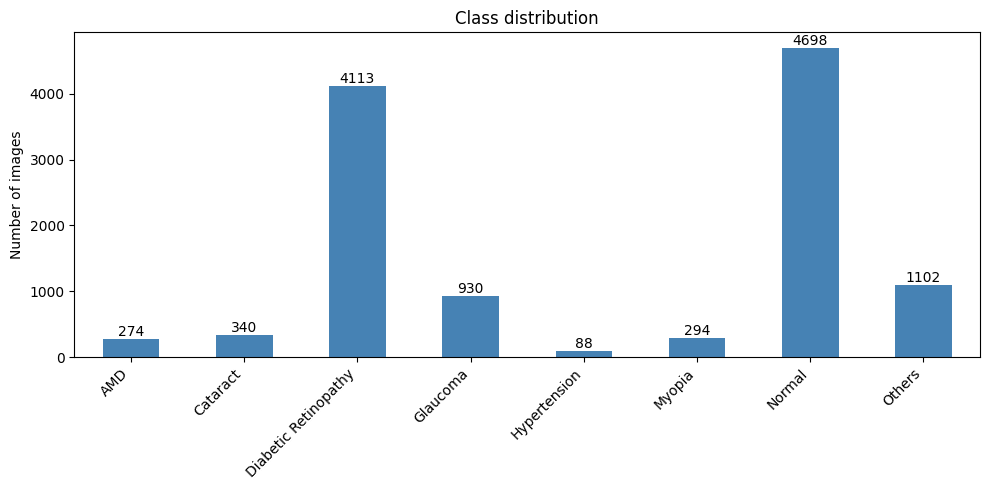

imbalance ratio (max/min): 53.4


In [9]:
counts = meta['y'].value_counts().sort_index()
counts.index = class_names

plt.figure(figsize=(10, 5))
ax = counts.plot(kind='bar', color='steelblue')
ax.bar_label(ax.containers[0])
plt.title('Class distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('imbalance ratio (max/min):', round(counts.max() / counts.min(), 1))

## 5. Sample images per class

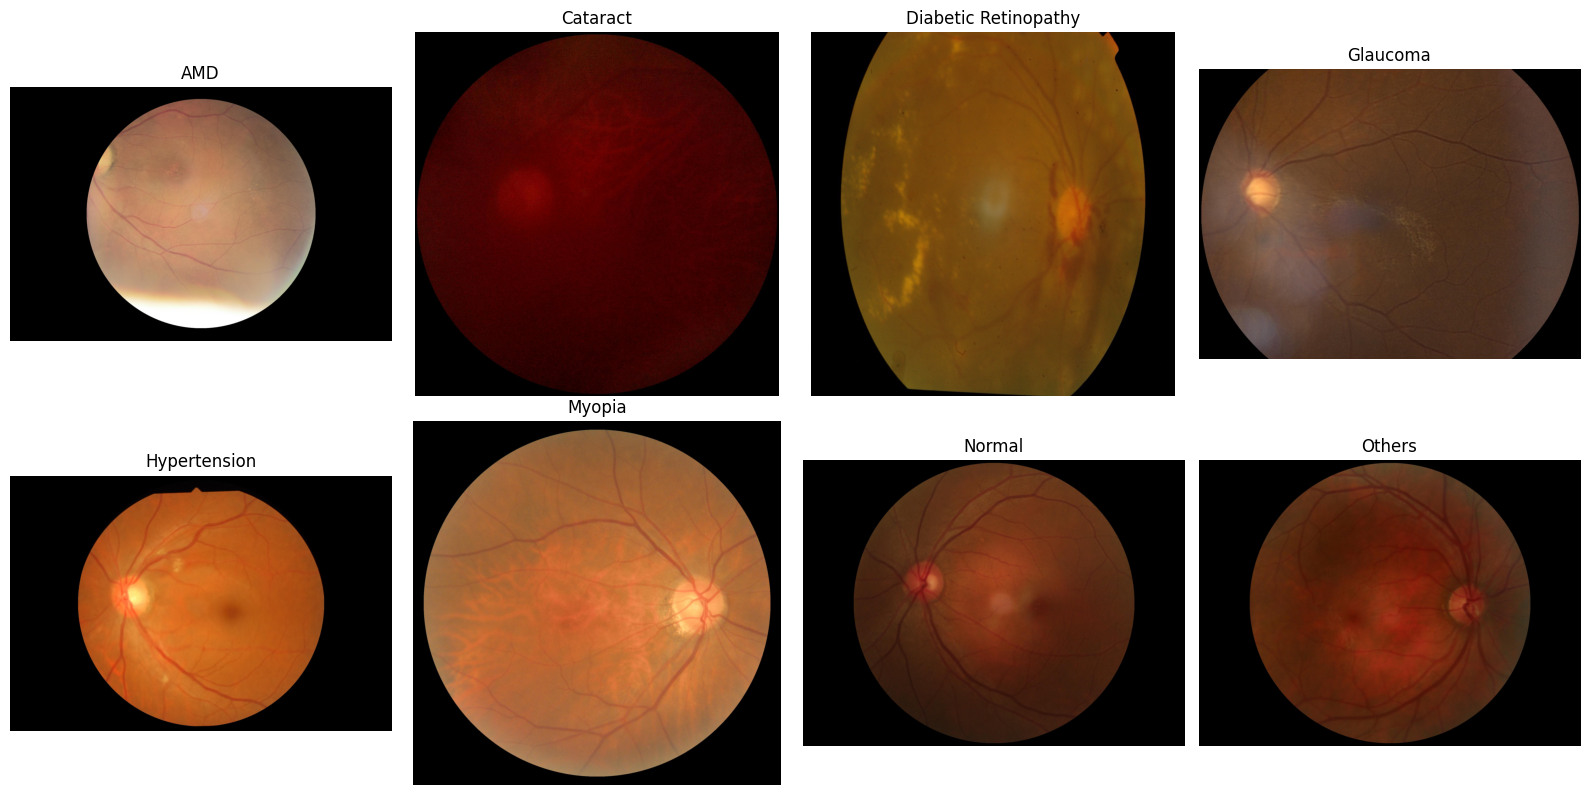

In [10]:
plt.figure(figsize=(16, 8))
for i, c in enumerate(classes):
    row = meta[meta[LABEL_COL] == c].sample(1, random_state=SEED).iloc[0]
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row['path']).convert('RGB'))
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Check image sizes before deciding on an input size

In [11]:
sizes = []
for p in meta['path']:
    with Image.open(p) as im:
        sizes.append((im.width, im.height, im.mode))

size_df = pd.DataFrame(sizes, columns=['width', 'height', 'mode'])
size_df['ratio'] = size_df['width'] / size_df['height']
print(size_df[['width', 'height', 'ratio']].describe())
print(size_df['mode'].value_counts())

              width        height         ratio
count  11839.000000  11839.000000  11839.000000
mean    1804.145789   1415.201960      1.221410
std      942.329905    602.068855      0.241927
min      178.000000    178.000000      0.995280
25%     1000.000000   1000.000000      1.000000
50%     1936.000000   1444.000000      1.012658
75%     2592.000000   1728.000000      1.500000
max     5184.000000   3456.000000      2.150056
mode
RGB    11839
Name: count, dtype: int64


In [12]:
low, high = 255, 0
for p in meta['path'].sample(300, random_state=SEED):
    a = np.array(Image.open(p).convert('RGB'))
    low, high = min(low, int(a.min())), max(high, int(a.max()))
print('pixel value range:', low, high)

pixel value range: 0 255


Sizes range from 178px up to 5184px and most are close to square, so resizing to a fixed square input is fine. Using 300x300 instead of 224x224 this time since the images have enough detail to justify it and both backbones support it.

## 7. Train / validation / test split

In [13]:
val_names = set(val_csv[FILE_COL].astype(str).apply(os.path.basename))
val_df = meta[meta['name'].isin(val_names)]
rest = meta[~meta['name'].isin(val_names)]

train_df, test_df = train_test_split(
    rest, test_size=len(val_df) / len(rest), stratify=rest['y'], random_state=SEED)

split_table = pd.DataFrame({
    'train': train_df['y'].value_counts().sort_index(),
    'val': val_df['y'].value_counts().sort_index(),
    'test': test_df['y'].value_counts().sort_index()})
split_table.index = class_names
print(split_table)
print(len(train_df), len(val_df), len(test_df))

                      train  val  test
AMD                     218   28    28
Cataract                272   34    34
Diabetic Retinopathy   3272  426   415
Glaucoma                743   93    94
Hypertension             70    9     9
Myopia                  234   30    30
Normal                 3755  467   476
Others                  881  110   111
9445 1197 1197


## 8. Input pipeline

In [14]:
IMG = 300
BATCH = 24

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG, IMG))
    return img, label

def make_ds(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['y'].values))
    if training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds = make_ds(val_df)
test_ds = make_ds(test_df)
y_test = test_df['y'].values

I0000 00:00:1790272570.588774      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790272570.591378      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 9. Class imbalance

Scratch CNN uses class weights. The two pretrained models use an oversampled training set instead, sampling each class with equal probability, since that actually shows the model more rare-class images per epoch instead of just scaling the gradient.

In [15]:
weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_df['y'])
class_weight = dict(enumerate(weights))
for i, w in class_weight.items():
    print(class_names[i], round(w, 2))

AMD 5.42
Cataract 4.34
Diabetic Retinopathy 0.36
Glaucoma 1.59
Hypertension 16.87
Myopia 5.05
Normal 0.31
Others 1.34


In [16]:
def make_balanced_ds(df):
    per_class = [df[df['y'] == c] for c in range(num_classes)]
    datasets = []
    for sub in per_class:
        ds = tf.data.Dataset.from_tensor_slices((sub['path'].values, sub['y'].values))
        ds = ds.shuffle(len(sub), seed=SEED).repeat()
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        datasets.append(ds)
    ds = tf.data.Dataset.sample_from_datasets(datasets, weights=[1 / num_classes] * num_classes)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds_balanced = make_balanced_ds(train_df)
steps_per_epoch = len(train_df) // BATCH

## 10. Augmentation (training only, done inside the model)

In [17]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

## 11. Helper functions

In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

def plot_history(histories, title):
    loss = sum([h.history['loss'] for h in histories], [])
    val_loss = sum([h.history['val_loss'] for h in histories], [])
    acc = sum([h.history['accuracy'] for h in histories], [])
    val_acc = sum([h.history['val_accuracy'] for h in histories], [])
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(loss, label='train')
    plt.plot(val_loss, label='val')
    plt.title(title + ' loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(acc, label='train')
    plt.plot(val_acc, label='val')
    plt.title(title + ' accuracy')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

def evaluate(model, name):
    y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    print(name)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    return classification_report(y_test, y_pred, target_names=class_names,
                                 zero_division=0, output_dict=True)

def ms_per_image(model):
    x, _ = next(iter(test_ds))
    model.predict(x, verbose=0)
    start = time.time()
    for _ in range(10):
        model.predict(x, verbose=0)
    return (time.time() - start) / (10 * len(x)) * 1000

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.tight_layout()
    plt.show()

## 12. Model 1: simple CNN from scratch

In [19]:
def build_cnn():
    return models.Sequential([
        layers.Input((IMG, IMG, 3)),
        layers.Rescaling(1 / 255),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')])

cnn = build_cnn()
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,376 (1009.28 KB)

 Trainable params: 258,376 (1009.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


2026-09-24 17:56:19.204245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:56:19.370355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:56:21.037007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:56:21.357250: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/394 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.1562 - loss: 1.4557  

I0000 00:00:1790272585.160885     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.1645 - loss: 2.0075

2026-09-24 17:57:19.055806: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:57:19.221921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:57:20.240817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 17:57:20.546802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


394/394 ━━━━━━━━━━━━━━━━━━━━ 80s 175ms/step - accuracy: 0.1650 - loss: 1.9634 - val_accuracy: 0.2640 - val_loss: 1.8260
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.2273 - loss: 1.8541 - val_accuracy: 0.2364 - val_loss: 1.7260
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 61s 153ms/step - accuracy: 0.2902 - loss: 1.7846 - val_accuracy: 0.2991 - val_loss: 1.8332
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.3006 - loss: 1.7293 - val_accuracy: 0.3074 - val_loss: 1.6026
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.3091 - loss: 1.6949 - val_accuracy: 0.3141 - val_loss: 1.6125
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.3110 - loss: 1.6883 - val_accuracy: 0.2924 - val_loss: 1.6961
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.3149 - loss: 1.6597 - val_accuracy: 0.3116 - val_loss: 1.6314
Epoch 8/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.3229 - loss: 1.6415 - val

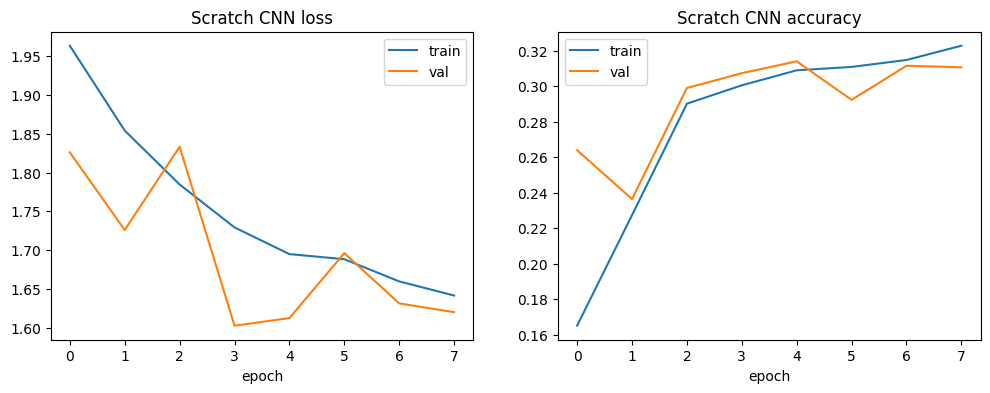

In [20]:
cnn_hist = cnn.fit(train_ds, validation_data=val_ds, epochs=20,
                   class_weight=class_weight, callbacks=[early_stop])
plot_history([cnn_hist], 'Scratch CNN')

In [21]:
normal_idx = class_names.index('Normal')

def add_disease_col(df):
    df = df.copy()
    df['is_disease'] = (df['y'] != normal_idx).astype(int)
    return df

train_df_bin = add_disease_col(train_df)
val_df_bin = add_disease_col(val_df)
test_df_bin = add_disease_col(test_df)

def make_ds_generic(df, label_col, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df[label_col].values))
    if training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds_bin = make_ds_generic(train_df_bin, 'is_disease', training=True)
val_ds_bin = make_ds_generic(val_df_bin, 'is_disease')
test_ds_bin = make_ds_generic(test_df_bin, 'is_disease')

In [22]:
def build_binary_model(base_model_fn, preprocess_fn):
    base = base_model_fn(include_top=False, weights='imagenet', input_shape=(IMG, IMG, 3))
    base.trainable = False
    inputs = layers.Input((IMG, IMG, 3))
    x = augment(inputs)
    x = layers.Lambda(preprocess_fn)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    return models.Model(inputs, outputs), base

screen_model, screen_base = build_binary_model(
    tf.keras.applications.DenseNet121, tf.keras.applications.densenet.preprocess_input)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [26]:

screen_model.compile(optimizer=cosine_optimizer(1e-3, epochs=5),
                     loss='binary_crossentropy', metrics=['accuracy'])
screen_hist1 = screen_model.fit(train_ds_bin, validation_data=val_ds_bin, epochs=5,
                                callbacks=[early_stop])


Epoch 1/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - accuracy: 0.6383 - loss: 0.6612 - val_accuracy: 0.7302 - val_loss: 0.5327
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.6879 - loss: 0.5822 - val_accuracy: 0.7343 - val_loss: 0.5257
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.7076 - loss: 0.5593 - val_accuracy: 0.7435 - val_loss: 0.5187
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.7069 - loss: 0.5594 - val_accuracy: 0.7494 - val_loss: 0.5144
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.7129 - loss: 0.5522 - val_accuracy: 0.7519 - val_loss: 0.5130


Epoch 1/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 108s 234ms/step - accuracy: 0.7006 - loss: 0.5931 - val_accuracy: 0.7678 - val_loss: 0.4866
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7296 - loss: 0.5458 - val_accuracy: 0.7719 - val_loss: 0.4773
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7496 - loss: 0.5163 - val_accuracy: 0.7778 - val_loss: 0.4564
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7567 - loss: 0.4944 - val_accuracy: 0.7761 - val_loss: 0.4452
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7627 - loss: 0.4771 - val_accuracy: 0.7820 - val_loss: 0.4410
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 222ms/step - accuracy: 0.7699 - loss: 0.4603 - val_accuracy: 0.7803 - val_loss: 0.4353
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7766 - loss: 0.4540 - val_accuracy: 0.7778 - val_loss: 0.4310
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 88s 223ms/step - accuracy: 0.7749 - loss: 

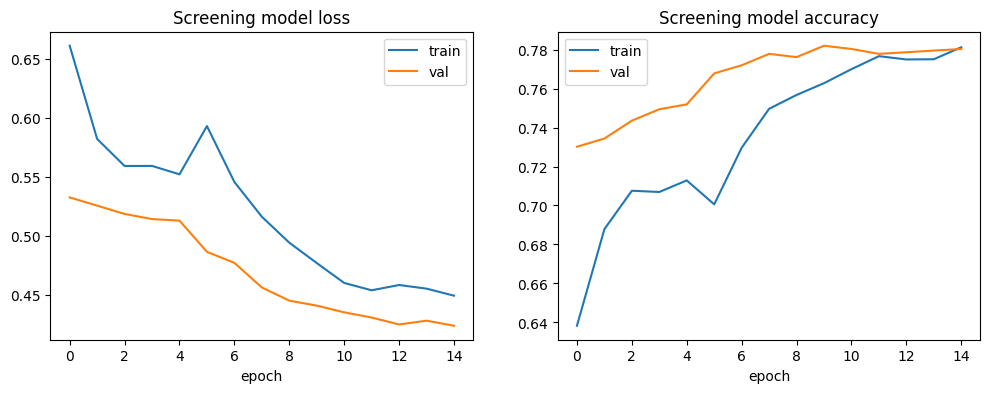

In [27]:
unfreeze_last(screen_base, 20)
screen_model.compile(optimizer=cosine_optimizer(1e-4, epochs=10),
                     loss='binary_crossentropy', metrics=['accuracy'])
screen_hist2 = screen_model.fit(train_ds_bin, validation_data=val_ds_bin, epochs=10,
                                callbacks=[early_stop])
plot_history([screen_hist1, screen_hist2], 'Screening model')

In [42]:
disease_classes = [c for c in class_names if c != 'Normal']
old_to_new = {old_i: new_i for new_i, old_i in enumerate(i for i in range(num_classes) if i != normal_idx)}
new_to_old = {v: k for k, v in old_to_new.items()}

disease_train_df = train_df[train_df['y'] != normal_idx].copy()
disease_val_df = val_df[val_df['y'] != normal_idx].copy()
for df in (disease_train_df, disease_val_df):
    df['y2'] = df['y'].map(old_to_new)

def make_balanced_ds_generic(df, label_col, n_classes):
    per_class = [df[df[label_col] == c] for c in range(n_classes)]
    datasets = []
    for sub in per_class:
        ds = tf.data.Dataset.from_tensor_slices((sub['path'].values, sub[label_col].values))
        ds = ds.shuffle(len(sub), seed=SEED).repeat()
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        datasets.append(ds)
    ds = tf.data.Dataset.sample_from_datasets(datasets, weights=[1 / n_classes] * n_classes)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

disease_train_ds = make_balanced_ds_generic(disease_train_df, 'y2', len(disease_classes))
disease_val_ds = make_ds_generic(disease_val_df, 'y2')
disease_steps = len(disease_train_df) // BATCH

def build_transfer_model_n(base_model_fn, preprocess_fn, n_out):
    base = base_model_fn(include_top=False, weights='imagenet', input_shape=(IMG, IMG, 3))
    base.trainable = False
    inputs = layers.Input((IMG, IMG, 3))
    x = augment(inputs)
    x = layers.Lambda(preprocess_fn)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_out, activation='softmax',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    return models.Model(inputs, outputs), base

def cosine_optimizer(lr, epochs, steps=None, weight_decay=1e-5):
    steps = steps_per_epoch if steps is None else steps
    schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=lr, decay_steps=steps * epochs)
    return tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=weight_decay)

def unfreeze_last(base, n):
    base.trainable = True
    for layer in base.layers[:-n]:
        layer.trainable = False


disease_model, disease_base = build_transfer_model_n(
    tf.keras.applications.DenseNet121, tf.keras.applications.densenet.preprocess_input,
    len(disease_classes))




In [29]:
disease_model.compile(optimizer=cosine_optimizer(1e-3, epochs=5),
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                      metrics=['accuracy'])
dis_hist1 = disease_model.fit(disease_train_ds, validation_data=disease_val_ds, epochs=5,
                              steps_per_epoch=disease_steps, callbacks=[early_stop])

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 72s 248ms/step - accuracy: 0.4035 - loss: 1.6826 - val_accuracy: 0.4589 - val_loss: 1.4787
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 52s 222ms/step - accuracy: 0.5197 - loss: 1.3409 - val_accuracy: 0.4890 - val_loss: 1.2237
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.5438 - loss: 1.2475 - val_accuracy: 0.5000 - val_loss: 1.3404
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.5543 - loss: 1.2182 - val_accuracy: 0.5151 - val_loss: 1.2100


Epoch 1/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 76s 254ms/step - accuracy: 0.5563 - loss: 1.2775 - val_accuracy: 0.4877 - val_loss: 1.2945
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 235ms/step - accuracy: 0.5601 - loss: 1.2275 - val_accuracy: 0.5205 - val_loss: 1.1898
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 234ms/step - accuracy: 0.6057 - loss: 1.1236 - val_accuracy: 0.5164 - val_loss: 1.2479
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 234ms/step - accuracy: 0.6090 - loss: 1.0990 - val_accuracy: 0.5288 - val_loss: 1.1931
Epoch 5/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 237ms/step - accuracy: 0.6399 - loss: 1.0319 - val_accuracy: 0.5575 - val_loss: 1.1628
Epoch 6/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 234ms/step - accuracy: 0.6581 - loss: 0.9777 - val_accuracy: 0.5740 - val_loss: 1.0880
Epoch 7/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 234ms/step - accuracy: 0.6770 - loss: 0.9168 - val_accuracy: 0.5384 - val_loss: 1.1370
Epoch 8/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 234ms/step - accuracy: 0.6823 - loss: 0

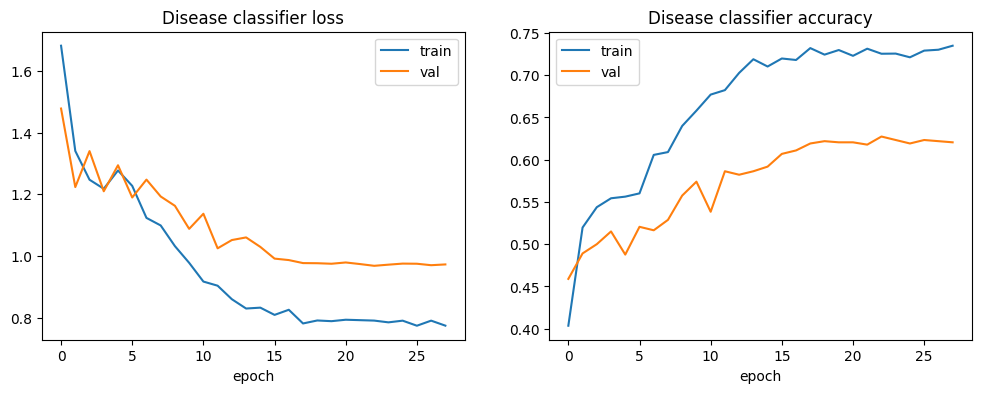

In [34]:

unfreeze_last(disease_base, 20)
disease_model.compile(optimizer=cosine_optimizer(1e-4, epochs=10),
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                      metrics=['accuracy'])
dis_hist2 = disease_model.fit(disease_train_ds, validation_data=disease_val_ds, epochs=30,
                              steps_per_epoch=disease_steps, callbacks=[early_stop])
plot_history([dis_hist1, dis_hist2], 'Disease classifier')

In [39]:
screen_model_eff, screen_base_eff = build_binary_model(
    tf.keras.applications.EfficientNetB0, tf.keras.applications.efficientnet.preprocess_input)

screen_model_eff.compile(optimizer=cosine_optimizer(1e-3, epochs=5),
                         loss='binary_crossentropy', metrics=['accuracy'])
screen_eff_hist1 = screen_model_eff.fit(train_ds_bin, validation_data=val_ds_bin, epochs=5,
                                        callbacks=[early_stop])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


E0000 00:00:1790278356.035384      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


394/394 ━━━━━━━━━━━━━━━━━━━━ 77s 169ms/step - accuracy: 0.6812 - loss: 0.5908 - val_accuracy: 0.7034 - val_loss: 0.5433
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - accuracy: 0.7282 - loss: 0.5382 - val_accuracy: 0.7360 - val_loss: 0.5225
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 63s 161ms/step - accuracy: 0.7364 - loss: 0.5233 - val_accuracy: 0.7427 - val_loss: 0.5188
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - accuracy: 0.7338 - loss: 0.5248 - val_accuracy: 0.7377 - val_loss: 0.5144
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - accuracy: 0.7350 - loss: 0.5178 - val_accuracy: 0.7402 - val_loss: 0.5136


Epoch 1/10


E0000 00:00:1790278705.173212      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


394/394 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - accuracy: 0.7506 - loss: 0.5006 - val_accuracy: 0.7736 - val_loss: 0.4477
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 164ms/step - accuracy: 0.7700 - loss: 0.4595 - val_accuracy: 0.7786 - val_loss: 0.4255
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.7732 - loss: 0.4452 - val_accuracy: 0.7853 - val_loss: 0.4101
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 0.7886 - loss: 0.4194 - val_accuracy: 0.7878 - val_loss: 0.4065
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 64s 162ms/step - accuracy: 0.7913 - loss: 0.4169 - val_accuracy: 0.7803 - val_loss: 0.4097
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.7939 - loss: 0.4056 - val_accuracy: 0.7870 - val_loss: 0.4102
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.7963 - loss: 0.3985 - val_accuracy: 0.7886 - val_loss: 0.4079
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.8005 - loss: 0.3953 - val

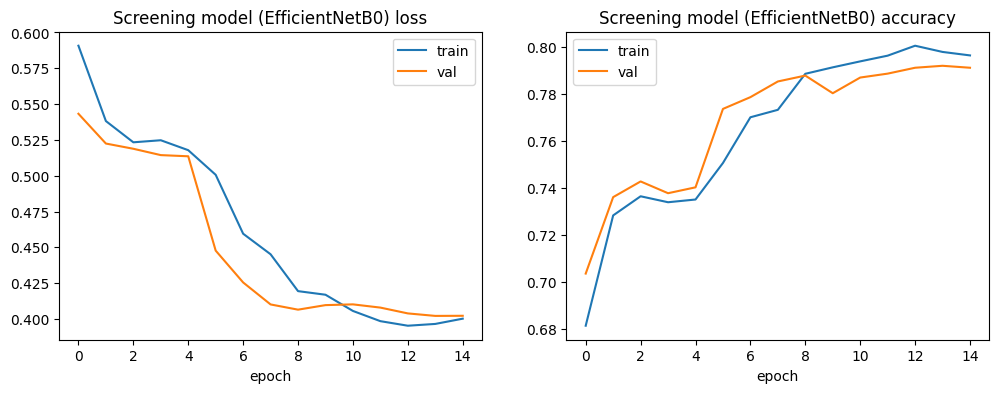

In [40]:
unfreeze_last(screen_base_eff, 20)
screen_model_eff.compile(optimizer=cosine_optimizer(1e-4, epochs=10),
                         loss='binary_crossentropy', metrics=['accuracy'])
screen_eff_hist2 = screen_model_eff.fit(train_ds_bin, validation_data=val_ds_bin, epochs=10,
                                        callbacks=[early_stop])
plot_history([screen_eff_hist1, screen_eff_hist2], 'Screening model (EfficientNetB0)')

In [43]:
disease_model_eff, disease_base_eff = build_transfer_model_n(
    tf.keras.applications.EfficientNetB0, tf.keras.applications.efficientnet.preprocess_input,
    len(disease_classes))

disease_model_eff.compile(optimizer=cosine_optimizer(1e-3, epochs=5, steps=disease_steps),
                          loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                          metrics=['accuracy'])
dis_eff_hist1 = disease_model_eff.fit(disease_train_ds, validation_data=disease_val_ds, epochs=5,
                                      steps_per_epoch=disease_steps, callbacks=[early_stop])

Epoch 1/5


E0000 00:00:1790279448.089272      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


237/237 ━━━━━━━━━━━━━━━━━━━━ 49s 163ms/step - accuracy: 0.4865 - loss: 1.3894 - val_accuracy: 0.5041 - val_loss: 1.3213
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 35s 149ms/step - accuracy: 0.5636 - loss: 1.1764 - val_accuracy: 0.5411 - val_loss: 1.1952
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 36s 152ms/step - accuracy: 0.5717 - loss: 1.1334 - val_accuracy: 0.5370 - val_loss: 1.1489
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 36s 153ms/step - accuracy: 0.5874 - loss: 1.1155 - val_accuracy: 0.5329 - val_loss: 1.2066
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - accuracy: 0.6050 - loss: 1.0865 - val_accuracy: 0.5151 - val_loss: 1.2267


Epoch 1/30


E0000 00:00:1790282124.418160      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


237/237 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.6788 - loss: 0.9054 - val_accuracy: 0.5384 - val_loss: 1.1385
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.6960 - loss: 0.8581 - val_accuracy: 0.5452 - val_loss: 1.1403
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.7201 - loss: 0.8046 - val_accuracy: 0.5781 - val_loss: 1.0274
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.7220 - loss: 0.7742 - val_accuracy: 0.5466 - val_loss: 1.1252
Epoch 5/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.7421 - loss: 0.7138 - val_accuracy: 0.5630 - val_loss: 1.0884


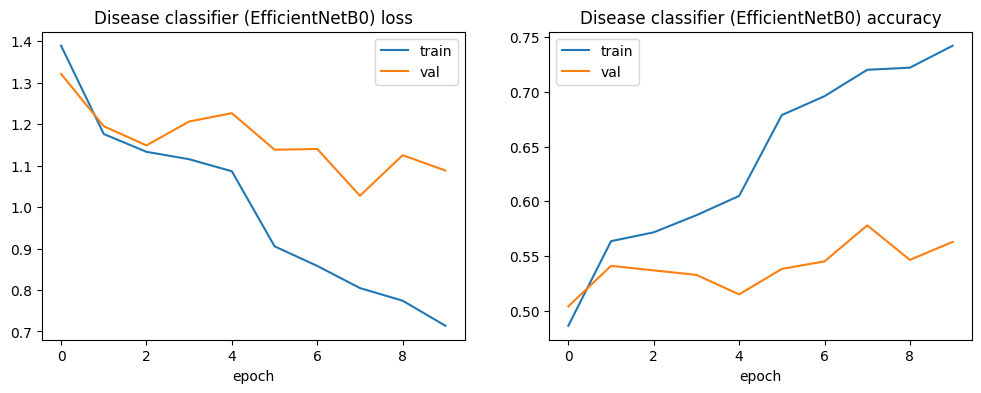

In [46]:
unfreeze_last(disease_base_eff, 20)
disease_model_eff.compile(optimizer=cosine_optimizer(1e-4, epochs=10, steps=disease_steps),
                          loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                          metrics=['accuracy'])
dis_eff_hist2 = disease_model_eff.fit(disease_train_ds, validation_data=disease_val_ds, epochs=30,
                                      steps_per_epoch=disease_steps, callbacks=[early_stop])
plot_history([dis_eff_hist1, dis_eff_hist2], 'Disease classifier (EfficientNetB0)')

In [35]:
screen_probs = screen_model.predict(test_ds, verbose=0).ravel()
disease_probs = disease_model.predict(test_ds, verbose=0)

y_pred_cascade = np.array([
    normal_idx if p < 0.5 else new_to_old[probs.argmax()]
    for p, probs in zip(screen_probs, disease_probs)])

print(classification_report(y_test, y_pred_cascade, target_names=class_names, zero_division=0))
cascade_report = classification_report(y_test, y_pred_cascade, target_names=class_names,
                                       zero_division=0, output_dict=True)

                      precision    recall  f1-score   support

                 AMD       0.24      0.71      0.35        28
            Cataract       0.27      0.82      0.40        34
Diabetic Retinopathy       0.83      0.56      0.67       415
            Glaucoma       0.61      0.53      0.57        94
        Hypertension       0.11      0.89      0.19         9
              Myopia       0.76      0.93      0.84        30
              Normal       0.86      0.59      0.70       476
              Others       0.22      0.41      0.29       111

            accuracy                           0.58      1197
           macro avg       0.49      0.68      0.50      1197
        weighted avg       0.73      0.58      0.62      1197



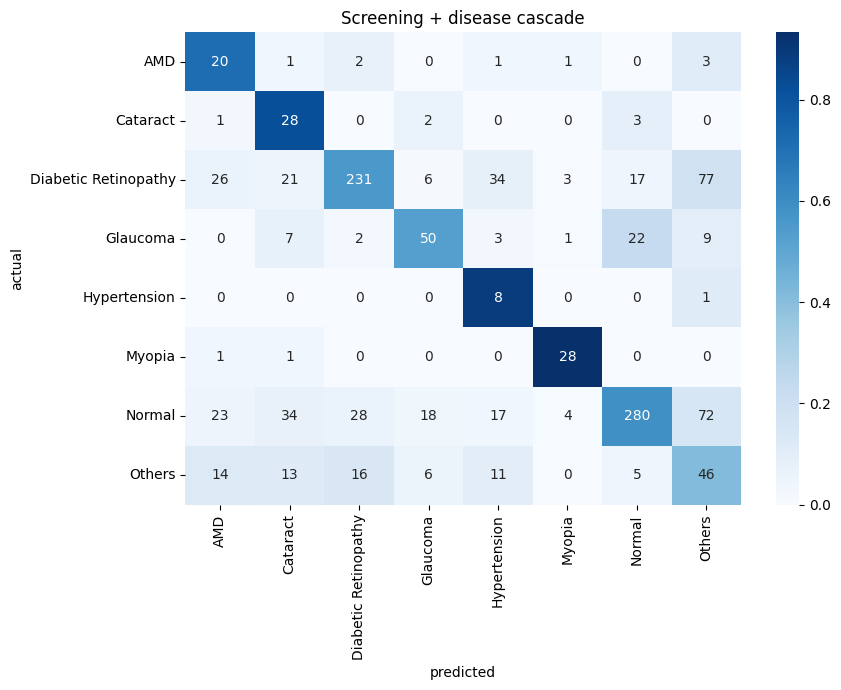

In [38]:
plot_confusion_matrix(y_test, y_pred_cascade, 'Screening + disease cascade')

In [47]:
screen_probs_eff = screen_model_eff.predict(test_ds, verbose=0).ravel()
disease_probs_eff = disease_model_eff.predict(test_ds, verbose=0)

y_pred_cascade_eff = np.array([
    normal_idx if p < 0.5 else new_to_old[probs.argmax()]
    for p, probs in zip(screen_probs_eff, disease_probs_eff)])

print(classification_report(y_test, y_pred_cascade_eff, target_names=class_names, zero_division=0))
cascade_eff_report = classification_report(y_test, y_pred_cascade_eff, target_names=class_names,
                                           zero_division=0, output_dict=True)

                      precision    recall  f1-score   support

                 AMD       0.15      0.75      0.25        28
            Cataract       0.48      0.88      0.62        34
Diabetic Retinopathy       0.95      0.44      0.60       415
            Glaucoma       0.60      0.55      0.58        94
        Hypertension       0.07      0.44      0.13         9
              Myopia       0.65      0.93      0.77        30
              Normal       0.84      0.66      0.74       476
              Others       0.23      0.51      0.32       111

            accuracy                           0.57      1197
           macro avg       0.50      0.65      0.50      1197
        weighted avg       0.77      0.57      0.62      1197



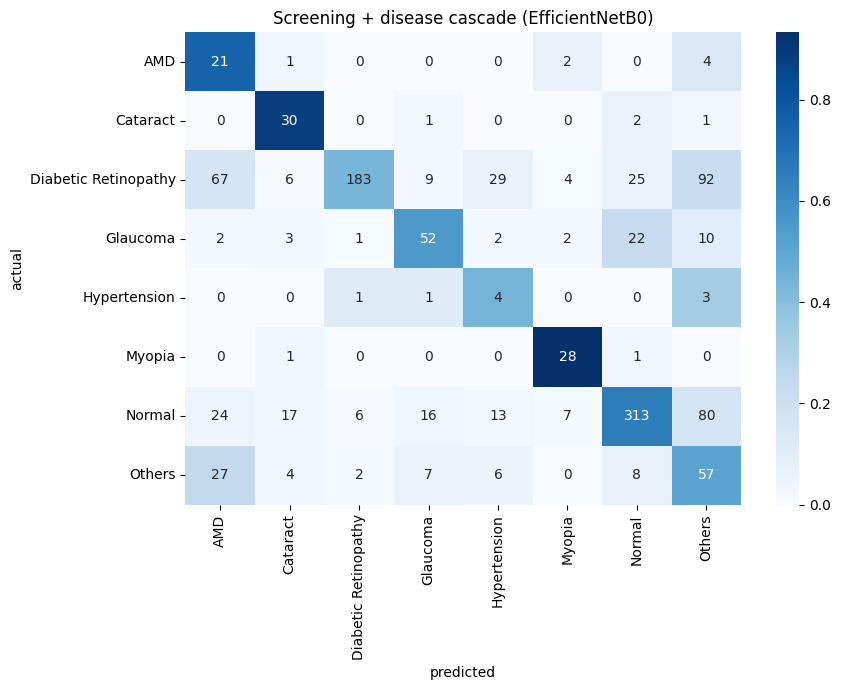

In [48]:
plot_confusion_matrix(y_test, y_pred_cascade_eff, 'Screening + disease cascade (EfficientNetB0)')